# Iceberg Demo

Sample fragmentation

In [2]:
import pandas as pd
import numpy as np
from collections import defaultdict

import ms_pred.magma.fragmentation as fe
from ms_pred.common.plot_utils import *
from ms_pred.dag_pred import joint_model

set_style()


%load_ext autoreload
%autoreload 2

In [3]:
def draw_single_mol(frag, engine):
    """Draw single molecule."""
    draw_dict = engine.get_draw_dict(frag)
    keep_atoms = draw_dict["hatoms"]
    keep_bonds = draw_dict["hbonds"]
    mol = draw_dict["mol"]
    # print(keep_atoms, keep_bonds)
    Chem.Kekulize(mol)
    drawing = Draw.MolToImage(mol, highlightAtoms=keep_atoms, highlightBonds=keep_bonds)
    return drawing

Get single example from NIST20


In [4]:
sample_labels = "../data/spec_datasets/sample_labels.tsv"
test_df = pd.read_csv(sample_labels, sep="\t")

# Get first entry from test_df for smiles and ionization
test_smiles = test_df.iloc[0]["smiles"]
test_ionization = test_df.iloc[0]["ionization"]

# test_smiles = "InChI=1S/C7H15NO3/c1-8(2,3)5-6(9)4-7(10)11/h6,9H,4-5H2,1-3H3/p+1"
test_smiles = "C[N+](C)(C)CC(CC(=O)O)O"
test_ionization = "[M+H]+"

Load models (run quickstart/iceberg/download_models.sh first to download)

In [5]:
device="cpu"

In [6]:
# Get best models
inten_ckpt = f"/local3/ericjiang/wgc/huaxu/ms/ms-pred/quickstart/iceberg/models/canopus_iceberg_score.ckpt"
gen_ckpt = f"/local3/ericjiang/wgc/huaxu/ms/ms-pred/quickstart/iceberg/models/canopus_iceberg_generate.ckpt"

# Load joint model
model = joint_model.JointModel.from_checkpoints(
    inten_checkpoint=inten_ckpt, gen_checkpoint=gen_ckpt, map_location=device
)

Lightning automatically upgraded your loaded checkpoint from v1.6.5 to v2.0.4. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint --file ../quickstart/iceberg/models/canopus_iceberg_generate.ckpt`
Lightning automatically upgraded your loaded checkpoint from v1.6.5 to v2.0.4. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint --file ../quickstart/iceberg/models/canopus_iceberg_score.ckpt`


In [7]:
# Predict example entry
# Model predict takes both a smiles string and an ionization
mol = Chem.MolFromSmiles(test_smiles)
outputs = model.predict_mol(
    mol=mol,
    smi=test_smiles,
    adduct=test_ionization,
    device="cpu",
    max_nodes=10,
    binned_out=False,
    threshold=0,
)

[17:38:15] WARNING: Proton(s) added/removed; Omitted undefined stereo

/home/ericjiang0318/miniconda3/envs/unified-ms-env/lib/python3.9/site-packages/dgl/backend/pytorch/tensor.py:53: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  return th.as_tensor(data, dtype=dtype)


The model output will contain 3 keys: "root_inchi", "name", and "frags"

1. root_inchi: Root inchi string
2. name: Often empty string used to specify a spectrum input
3. frags: Dictionary containing the predicted fragments

In particular, frags has keys corresponding to hash IDs of each subfragment, mapped to the intensities predicted at that value. Each value (outputs['frags']['key']) is itself a dictionary with the following keys:

1. frag: A binary representation corresponding to which atoms are present in the substructure
2. frag_hash: Unique hash of the substructure
3. parents: hash ids of the parent fragments in the predicted DAG
4. mz_no_charge: a list of mass values corresponding to various hydrogen rearrangements _less_ the mz of the precursor adduct
5. mz_charge: equivalent to mz_no_charge but adding the precursor adduct
6. intens: predicted intensity at each mz value
7. form: Molecular formula

In addition, for completeness, the following additional keys are also included:

8. atoms_pulled: Defines which atoms were removed from the molecule in the tree (can be ignored)
9. left_pred: Defines predictions at each of the atoms for their probability of leaving
10. max_broken: This defines how many bonds were broken in the DAG to reach the fragment of interest, which influences masking during generation
11. tree_depth: Tree depth on the DAG
12. id: A shorter ID not used elsewhere
13. prob_gen: The probability of observing this subfragment according to the first model
14. score: The score that the MAGMa heuristic applies to this fragment
15. frag_hs: The total number of hydrogens attached to the original fragment
16. max_remove_hs: maximum number of hs to remove
17. max_add_hs: Max hs to add

Below we show how to identify the fragments and plot the outputs

Binary repr of fragmentation number: 511


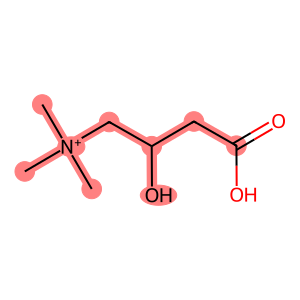

In [8]:
root_inchi = outputs["root_inchi"]
frags = outputs["frags"]

# Generate a fragmentation engine
engine = fe.FragmentEngine(mol_str=root_inchi, mol_str_type="inchi")

# Select a random fragment index to draw
frag_dicts = list(frags.items())
random_frag_ind = np.random.choice(len(frag_dicts))
random_frag = frag_dicts[random_frag_ind]

# Get "frag" the binary representation of which atoms are present and draw it
frag_num = random_frag[1]["frag"]
print(f"Binary repr of fragmentation number: {frag_num}")
draw_single_mol(frag_num, engine)

Below we show how to sum all intensities according to mz in order to generate a single spectrum

In [9]:
frags

{'1d5950a40bb7a53837637d1113896ecca4f5145cbb5add027775fc0a1740c27b': {'frag': 2047,
  'frag_hash': '1d5950a40bb7a53837637d1113896ecca4f5145cbb5add027775fc0a1740c27b',
  'parents': [],
  'atoms_pulled': [1, 9, 7, 10, 0, 2, 3, 6, 4],
  'left_pred': [0.9811416268348694,
   0.7324032783508301,
   0.6196234822273254,
   0.49200230836868286,
   0.2843877077102661,
   0.2843877077102661,
   0.2843877077102661,
   0.204924076795578,
   0.11244534701108932],
  'max_broken': 0,
  'tree_depth': 0,
  'id': 0,
  'prob_gen': 1,
  'score': 0,
  'form': 'C7NO3H16',
  'base_mass': 162.113018372,
  'frag_hs': 16,
  'max_remove_hs': 0,
  'max_add_hs': 0,
  'intens': [0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.019782261922955513,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0,
   0.0],
  'mz_no_charge': [156.06606818,
   157.073893212,
   158.081718244,
   159.089543276,
   160.097368308,
   161.10519334,
   162.113018372,
   163.120843404,
   164.128668436,
   165.136493468,
   166.1443185,
   167.1521435

In [14]:
len(frags)

10

In [11]:
# Convert from frags dict into a list of mz, inten
mass_to_obj = defaultdict(lambda: {})
for k, val in frags.items():
    masses, intens, form  = val["mz_charge"], val["intens"], val["form"]
    for m, i in zip(masses, intens):
        if i <= 0:
            continue
        cur_obj = mass_to_obj[m]
        if cur_obj.get("inten", 0) > 0:
            # update
            if cur_obj.get("inten") < i:
                cur_obj["frag_hash"] = k
                cur_obj['form'] = form
            cur_obj["inten"] += i
        else:
            cur_obj["inten"] = i
            cur_obj["frag_hash"] = k
            cur_obj['form'] = form

max_inten = max(*[i["inten"] for i in mass_to_obj.values()], 1e-9)
mass_to_obj = {
    k: dict(inten=v["inten"] / max_inten, frag_hash=v["frag_hash"], 
            form=v['form'])
            
    for k, v in mass_to_obj.items()
}

In [12]:

sorted(list(mass_to_obj.items()), key = lambda x: x[1]["inten"], reverse=True)[:10]

[(103.038970504,
  {'inten': 1.0,
   'frag_hash': '74a28b2eb10efab52a55f9f1410d4ef4f3e975f6a16f9d271c4b7a7a1bba946d',
   'form': 'C4O3H7'}),
 (104.046795536,
  {'inten': 0.0723718351206973,
   'frag_hash': '74a28b2eb10efab52a55f9f1410d4ef4f3e975f6a16f9d271c4b7a7a1bba946d',
   'form': 'C4O3H7'}),
 (163.120294824,
  {'inten': 0.05139693003291023,
   'frag_hash': '1d5950a40bb7a53837637d1113896ecca4f5145cbb5add027775fc0a1740c27b',
   'form': 'C7NO3H16'}),
 (67.017841136,
  {'inten': 0.02998954244767778,
   'frag_hash': '39b48f5f501d4356d338d61a8502a64c4f6d5c0413a43bd0a23e4e7dafc5bd11',
   'form': 'C4OH5'}),
 (73.064791328,
  {'inten': 0.029439283516645865,
   'frag_hash': '39b48f5f501d4356d338d61a8502a64c4f6d5c0413a43bd0a23e4e7dafc5bd11',
   'form': 'C4OH5'}),
 (71.049141264,
  {'inten': 0.02465707008199644,
   'frag_hash': '39b48f5f501d4356d338d61a8502a64c4f6d5c0413a43bd0a23e4e7dafc5bd11',
   'form': 'C4OH5'}),
 (105.054620568,
  {'inten': 0.01940903674566655,
   'frag_hash': '74a28b2eb10

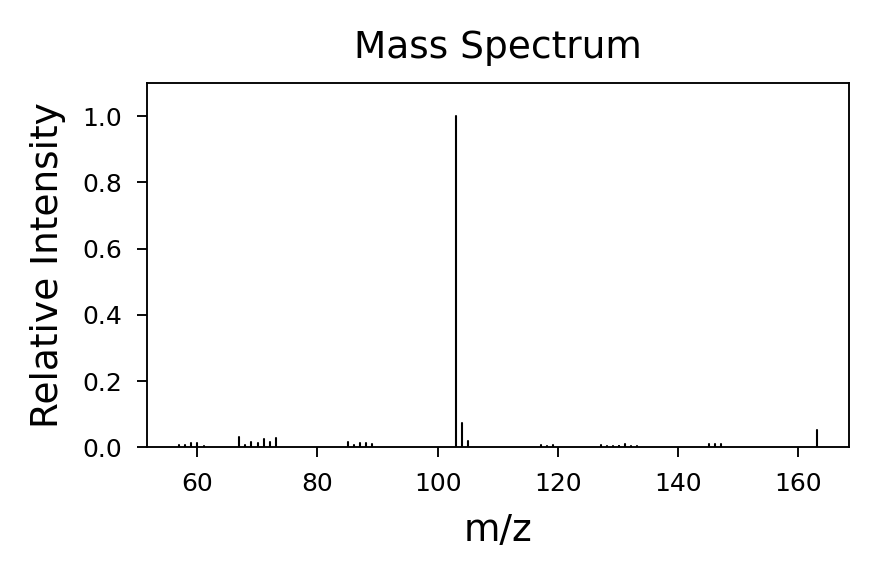

In [13]:
# Plot the output
fig = plt.figure(figsize=(3, 2), dpi=300)
for k, v in mass_to_obj.items():
    # Plot verticle line from k to v['inten']
    plt.plot([k, k], [0, v["inten"]], color="black", linewidth=0.5)
    # Can also get the frag id if we want to plot one of these in particular

plt.xlabel("m/z")
plt.ylabel("Relative Intensity")
plt.title("Mass Spectrum")
# Set ylim
plt.ylim(0, 1.1)
plt.tight_layout()